In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# 1. Load the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Normalize the data (scale pixels to [0,1])
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. One-hot encode the labels (e.g., 3 -> [0,0,0,1,0,0,0,0,0,0])
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 4. Build the ANN model
model = Sequential([
    Flatten(input_shape=(28, 28)),       
    Dense(128, activation='relu'),       
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),        
    Dense(10, activation='softmax')    
])

# 5. Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step


c:\Users\Acer\Desktop\Practice\.venv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [2]:
# 6. Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8302 - loss: 0.5553 - val_accuracy: 0.9623 - val_loss: 0.1248
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9631 - loss: 0.1250 - val_accuracy: 0.9682 - val_loss: 0.1056
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9742 - loss: 0.0845 - val_accuracy: 0.9738 - val_loss: 0.0884
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9815 - loss: 0.0587 - val_accuracy: 0.9802 - val_loss: 0.0786
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9854 - loss: 0.0462 - val_accuracy: 0.9795 - val_loss: 0.0797


In [3]:
# 7. Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9733 - loss: 0.0869
Test accuracy: 0.9756


In [4]:

#Testing >>>
import numpy as np

# Reshape the image to (1, 28, 28)
single_image = x_test[20].reshape(1, 28, 28)

# Make prediction
prediction = model.predict(single_image)
prediction

# Show the result
predicted_class = np.argmax(prediction)
print(f"Predicted digit: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicted digit: 9


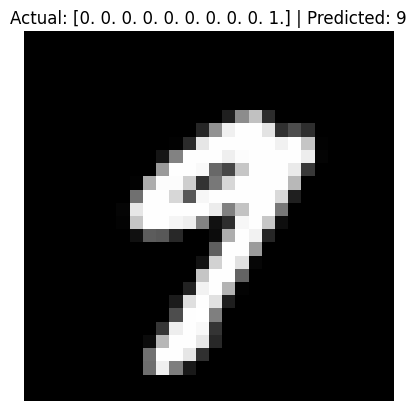

In [5]:
import matplotlib.pyplot as plt

plt.imshow(x_test[20], cmap='gray')
plt.title(f"Actual: {y_test[20]} | Predicted: {predicted_class}")
plt.axis('off')
plt.show()
